### 2. So sánh PCA 2D và t-SNE 2D (Phi tuyến)
t-SNE là một kỹ thuật phi tuyến mạnh mẽ để bảo tồn cấu trúc cục bộ của dữ liệu, giúp thấy rõ các cụm (clusters) mà PCA có thể bỏ lỡ.


Original shape: (11200, 263)
After sampling: (700, 263)


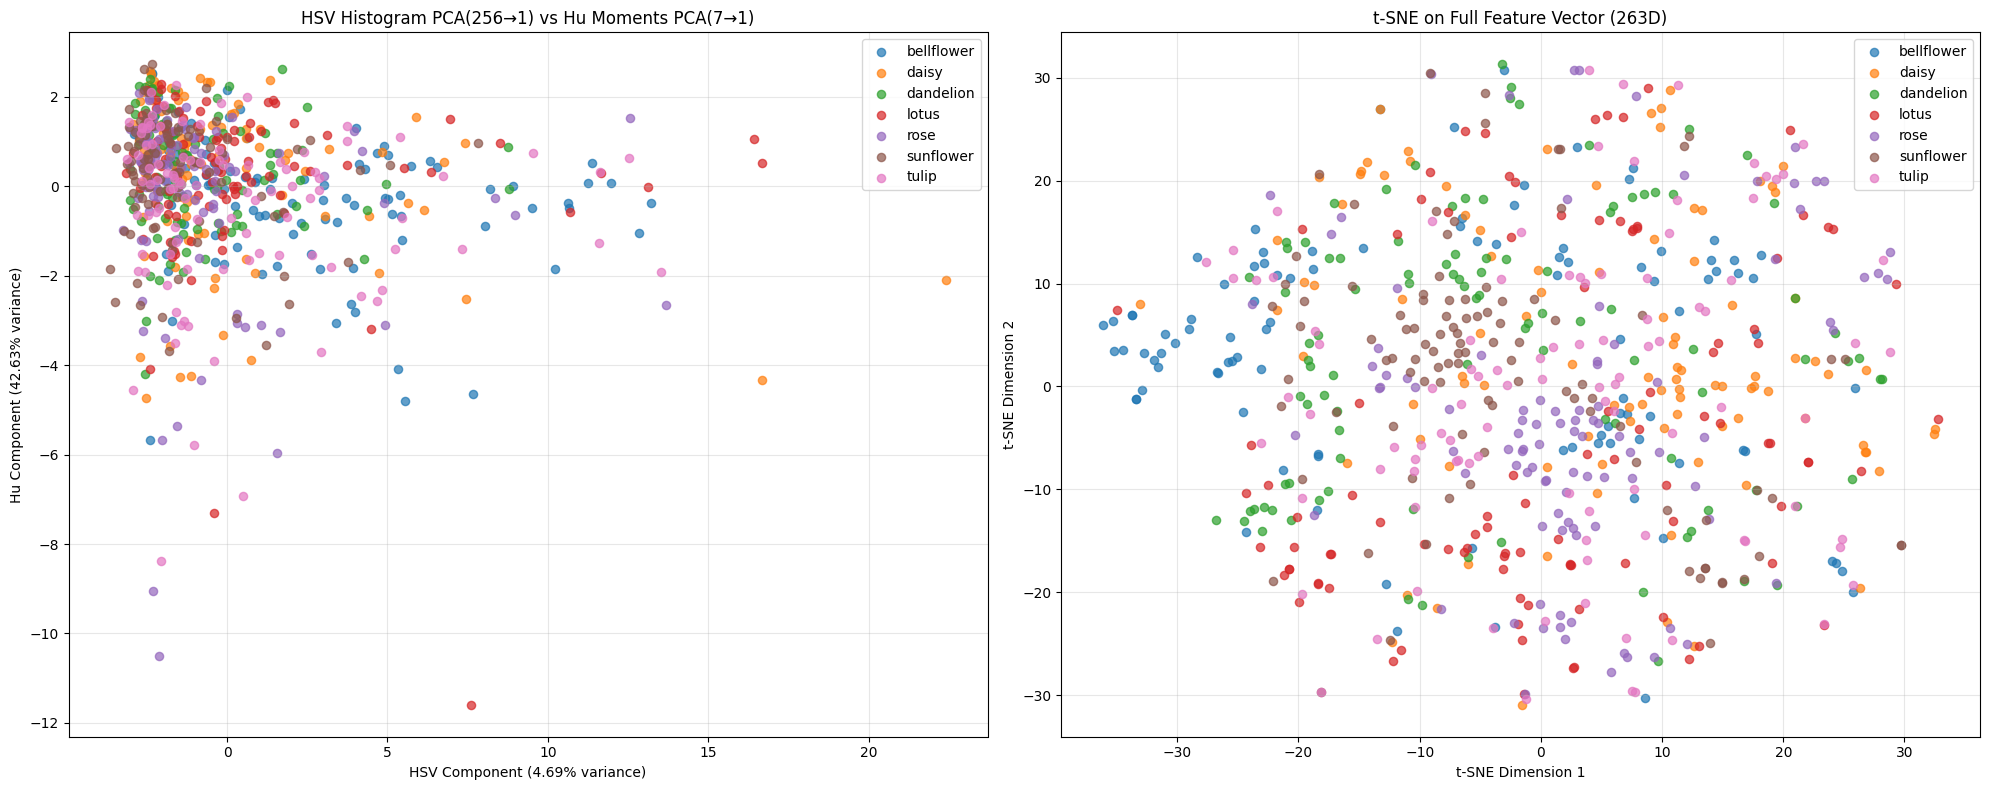

In [1]:
    import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ==========================
# Load dữ liệu
# ==========================

base_path = r"C:\Users\binhm\Documents\FlowerClassification\it3160\HuHSVHistSoftmaxModel"

X_path = os.path.join(base_path, "X_features.npy")
y_path = os.path.join(base_path, "y_labels.npy")
classes_path = os.path.join(base_path, "classes_mapping.npy")

X = np.load(X_path)
y = np.load(y_path)
class_names = np.load(classes_path, allow_pickle=True)

print(f"Original shape: {X.shape}")

# ==========================
# Lấy 100 mẫu ngẫu nhiên mỗi lớp
# ==========================

samples_per_class = 100
rng = np.random.default_rng(42)

selected_indices = []

for class_id in range(len(class_names)):
    class_indices = np.where(y == class_id)[0]

    n_select = min(samples_per_class, len(class_indices))

    chosen = rng.choice(
        class_indices,
        size=n_select,
        replace=False
    )

    selected_indices.extend(chosen)

selected_indices = np.array(selected_indices)

X = X[selected_indices]
y = y[selected_indices]

print(f"After sampling: {X.shape}")

# ==========================
# Chuẩn hóa
# ==========================

X_scaled = StandardScaler().fit_transform(X)

# ==========================
# Tách HSV và Hu Moments
# ==========================
# 0 -> 255 : HSV Histogram
# 256 -> 262 : Hu Moments
# ==========================

X_hsv = X_scaled[:, :256]
X_hu = X_scaled[:, 256:]

# ==========================
# PCA riêng cho HSV
# ==========================

pca_hsv = PCA(
    n_components=1,
    random_state=42
)

hsv_component = pca_hsv.fit_transform(X_hsv)

# ==========================
# PCA riêng cho Hu Moments
# ==========================

pca_hu = PCA(
    n_components=1,
    random_state=42
)

hu_component = pca_hu.fit_transform(X_hu)

# ==========================
# Không gian 2D:
# X = HSV
# Y = Hu
# ==========================

X_custom = np.hstack([
    hsv_component,
    hu_component
])

# ==========================
# t-SNE trên toàn bộ vector
# ==========================

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_scaled)

# ==========================
# Vẽ biểu đồ
# ==========================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(20, 8)
)

for class_id, class_name in enumerate(class_names):

    mask = y == class_id

    # HSV vs HU
    ax1.scatter(
        X_custom[mask, 0],
        X_custom[mask, 1],
        label=class_name,
        alpha=0.7,
        s=35
    )

    # t-SNE
    ax2.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        label=class_name,
        alpha=0.7,
        s=35
    )

# ==========================
# Biểu đồ HSV-HU
# ==========================

ax1.set_title(
    "HSV Histogram PCA(256→1) vs Hu Moments PCA(7→1)"
)

ax1.set_xlabel(
    f"HSV Component "
    f"({pca_hsv.explained_variance_ratio_[0] * 100:.2f}% variance)"
)

ax1.set_ylabel(
    f"Hu Component "
    f"({pca_hu.explained_variance_ratio_[0] * 100:.2f}% variance)"
)

ax1.grid(True, alpha=0.3)

# ==========================
# Biểu đồ t-SNE
# ==========================

ax2.set_title(
    "t-SNE on Full Feature Vector (263D)"
)

ax2.set_xlabel("t-SNE Dimension 1")
ax2.set_ylabel("t-SNE Dimension 2")

ax2.grid(True, alpha=0.3)

# ==========================
# Legend
# ==========================

ax1.legend(loc="best")
ax2.legend(loc="best")

plt.tight_layout()
plt.show()



### 3. Khảo sát t-SNE với các tham số Perplexity khác nhau
Perplexity có thể coi là ước lượng số lượng láng giềng gần của mỗi điểm. Thay đổi tham số này giúp quan sát dữ liệu ở các quy mô khác nhau (global vs local structure).
